In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

In [2]:
import glob
import pandas as pd
# sys.path.append('ensgen/')

In [3]:
# from ensgen import ensgen

# Functions

In [24]:
import glob, pybedtools, sys, os, subprocess, shutil, pyBigWig, re, random
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import multiprocessing as mp
import seaborn as sns
import pandas as pd
import numpy as np

from multiprocessing import Pool
from scipy import stats
from tqdm import tqdm

class ensgen():

    def __init__(self, genetic=None, tmp="tmp", folds="folds", number_of_folds=5, output="output", genome="hg38", n_subsampling=1000, seed=None, info=None, beds=None, bigwigs=None):
        
        if (info==None) | (beds==None) | (bigwigs==None):
            print("info, beds, and bigwigs must be provided.")
            sys.exit(0)

        self.seed = seed
        if (self.seed != None) and (isinstance(self.seed , int)):
            random.seed(self.seed)
            np.random.seed(self.seed)

        self.genetic = genetic

        self.tmp = tmp
        self.folds = folds
        self.output = output
        self.number_of_folds = number_of_folds
        self.genome = genome
        self.n_subsampling = n_subsampling


        self.mappable_bp = 3049315783 #https://genomewiki.ucsc.edu/index.php?title=Hg38_27-way_Genome_size_statistics
        self.background = "https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/AVOCATO/1000genomes/ALL_1000_genomes.variants.hg38.bed"

        self.df_input = pd.DataFrame()
        
        self.url_input_info = info
        
        self.url_input_beds = beds

        self.url_input_bigwigs = bigwigs


    def __download_background(self):

        if not os.path.exists(self.folds):
            os.makedirs(self.folds)

        if not os.path.exists(self.folds+os.sep+"ALL_1000_genomes.variants.%s.bed"%self.genome):
            print("Downloading %s ALL 1000 genomes background..."%self.genome)
            _ = subprocess.run('wget -P %s/ %s'%(self.folds, self.background), shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


    def shuf(self, x):

            return subprocess.run(x, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


    def __shuffle_background(self, number_of_genetic):

        print("For each fold, parallelised shuffling background ...")

        commands = []
        for f in range(1, self.number_of_folds+1):
            commands.append("shuf -n %s %s | sort -k1,1 -k2,2n > %s/SUB%s.bed"%(number_of_genetic, self.folds+os.sep+"ALL_1000_genomes.variants.%s.bed"%self.genome, self.folds, f))

        with Pool() as pool:
            _ = pool.map(self.shuf, commands)


    def __create_background(self, number_of_genetic): 

        self.__download_background()
        self.__shuffle_background(number_of_genetic)


    def __add_shuffled_background(self, df_data, beds): # it can be parallelised as __shuffle_background

        print("Adding shuffled background ...")
        for idx, fold in enumerate(tqdm(glob.glob("%s/SUB*.bed"%self.folds))):
            df_fold = pd.read_csv(fold, sep="\t", header=None)[[0,1,2]]

            xs_fold = []
            df_bed = pybedtools.BedTool.from_dataframe(df_fold)
            for bed in beds:
                try:
                    tmp = pd.read_csv(bed, sep="\t")
                    tmp_bed = pybedtools.BedTool.from_dataframe(tmp)
                    intersect_bed = df_bed.intersect(tmp_bed)
                    intersect_bed = intersect_bed.to_dataframe()
                    xs_fold.append(intersect_bed.shape[0])
                except:
                    xs_fold.append(0.0)
            df_data["bg_%s"%(idx+1)] = xs_fold		

        return df_data


    def __add_statistics(self, df_data, number_of_genetic):

        print("Calculating statistics ...")

        df_data["P_gwas"] = stats.binom.pmf(df_data["GWAS_init"], number_of_genetic, df_data["p_succes"])

        for f in range(1, self.number_of_folds+1):
            df_data["P_ss%s"%f]  = stats.binom.pmf(df_data["bg_%s"%f], number_of_genetic, df_data["p_succes"])
            df_data["FOLD%s"%f] = -np.log10(df_data["P_gwas"])/-np.log10(df_data["P_ss%s"%f])
        col = df_data.loc[: , "FOLD1":"FOLD%s"%f]
        df_data['MEAN'] = col.mean(axis=1)

        return df_data


    def __clean_tmp(self):

        print("Cleaning temporary files ...")
        shutil.rmtree(self.tmp)


    def __check_genetic_format(self):

        if not os.path.exists(self.genetic):
            sys.exit("Error, gentic file does not exist.")

        df = pd.read_csv(self.genetic, sep="\t")

        try:
            df = df[~df['CHR_POS'].str.contains(";")] # check when happens
        except:
            pass

        print("Removing NaN rows from loaded file ...")
        try:
            df = df[["CHR_ID", "CHR_POS", "SNPS"]]
        except:
            sys.exit("Error, gentic file must contain at least 3 columns:  \
                        \n\t'CHR_ID': int or fload value, \
                        \n\t'CHR_POS': int or fload value, \
                        \n\t'SNPS': string value.")

        try:
            df = df[~df['CHR_POS'].str.contains(";")] # check when happens
        except:
            pass
        try:
            df = df[~df['CHR_POS'].str.contains("x")] # check when happens
        except:
            pass
        df = df.dropna()

        if df.shape[-1] == 1:
            sys.exit("Error, gentic file must be tab delimited.")

        if df.shape[-1] < 3:
            sys.exit("Error, gentic file must contain at least 3 columns:  \
                    \n\t'CHR_ID': int or fload value, \
                    \n\t'CHR_POS': int or fload value, \
                    \n\t'SNPS': string value.")

        if df.shape[-1] >= 3:
            if ("CHR_ID" not in df.columns) | ("CHR_POS" not in df.columns) | ("SNPS" not in df.columns):
                sys.exit("Error, gentic file must contain at least 3 columns:  \
                        \n\t'CHR_ID': int or fload value, \
                        \n\t'CHR_POS': int or fload value, \
                        \n\t'SNPS': string value.")

        try:
            df = df[~df['CHR_POS'].str.contains(";")] # check when happens
        except:
            pass
        try:
            df = df[~df['CHR_POS'].str.contains("x")] # check when happens
        except:
            pass
        df['CHR_POS'] = df['CHR_POS'].astype(int)
        # if df.dtypes["CHR_ID"] not in ['int32', 'int64', 'float32', 'float64']:
            # sys.exit("Error, column 'CHR_ID' does not contain all numeric values.")
        if df.dtypes["CHR_POS"] not in ['int32', 'int64', 'float32', 'float64']:
            sys.exit("Error, column 'CHR_POS' does not contain all numeric values.")
        if df.dtypes["SNPS"] not in ['str', 'object']:
            sys.exit("Error, column 'SNPS' does not contain all string/object values.")
            
            
    def __load_genetic(self, subsampling = False):

        self.__check_genetic_format()

        df = pd.read_csv(self.genetic, sep="\t")[["CHR_ID", "CHR_POS", "SNPS"]]

        df = df.dropna(subset=['CHR_ID'], axis=0)
        df["CHR_ID"] = df["CHR_ID"].astype(str)
        try:
            df = df[~df['CHR_POS'].str.contains(";")] # check when happens
        except:
            pass
        try:
            df = df[~df['CHR_POS'].str.contains("x")] # check when happens
        except:
            pass
        df["CHR_POS"] = df["CHR_POS"].astype(int)
        df["SNPS"] = df["SNPS"].astype(str)
        df["CHR_ID"] = "chr"+df["CHR_ID"].str.replace(".0", "", regex=False)
        df["CHR_ID"] = df["CHR_ID"].str.replace("chrchr", "chr", regex=False)
        df["CHR_POS+1"] = df["CHR_POS"]+1
        df = df.sort_values(["CHR_ID", "CHR_POS"])
        df = df.reset_index(drop=True)
        df = df[['CHR_ID', 'CHR_POS', 'CHR_POS+1', 'SNPS']]

        ### random subsampling
        if subsampling:
            if df.shape[0]>self.n_subsampling:
                print("Genetic subsampled.")
                # df = df.loc[np.random.choice(df.index, 500, replace=False)]
                df = df.sample(n=self.n_subsampling, frac=None, replace=False, weights=None, random_state=42, axis=0)
                df = df.reset_index(drop=True)

        self.genetic = df

        return df.shape[0]


    def __prepare_data(self, beds):

        df_data = pd.DataFrame()

        peak_area = []
        ps = []
        celltypes = []
        print("Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...")
        for bed in tqdm(beds):
            tmp = pd.read_csv(bed, sep="\t", names=["chrom", "start", "end"])
            
            celltype = bed.split("/")[-1].replace("_L-tron.bed","")
            celltypes.append(celltype)

            # total number of base-pairs within peaks
            tot_bp_within_peaks = np.sum(tmp['end']-tmp['start'])
            peak_area.append(tot_bp_within_peaks)
            # print(tot_bp_within_peaks)

            # total number of base-pairs within peaks divided by uniquely mappable base-pairs
            p = tot_bp_within_peaks/self.mappable_bp

            ps.append(p)

        df_data["Peak_area"] = peak_area
        df_data["p_succes"]  = ps
        df_data.index        = celltypes

        if not os.path.exists(self.tmp):
            os.makedirs(self.tmp)
        pybedtools.set_tempdir(self.tmp)

        xs = []
        df_bed = pybedtools.BedTool.from_dataframe(self.genetic)
        print("Intersecting genetic with peak regions ...")
        for bed in tqdm(beds):
            # try:
            tmp = pd.read_csv(bed, sep="\t", names=["chrom", "start", "end"])
            tmp_bed = pybedtools.BedTool.from_dataframe(tmp)
            intersect_bed = df_bed.intersect(tmp_bed)
            intersect_bed = intersect_bed.to_dataframe()
            xs.append(intersect_bed.shape[0])
            # except:
                # xs.append(0.0)
        df_data["GWAS_init"] = xs

        return df_data
        
        
    def __loading_input_beds(self):
        
        input_info = pd.read_csv(self.url_input_info, sep='\t', names=['cellType'])
        input_info = input_info.set_index('cellType', drop=True)

        input_beds = []
        for ct in input_info.index.tolist():
            input_beds.append("%s/%s_L-tron.bed"%(self.url_input_beds, ct))
        
        return input_beds


    def __loading_input_bigwig(self):

        input_info = pd.read_csv(self.url_input_info, sep='\t', names=['cellType'])
        input_info = input_info.set_index('cellType', drop=True)

        input_bigwigs = []
        for ct in input_info.index.tolist():
            input_bigwigs.append("%s/%s.bw"%(self.url_input_bigwigs, ct))
            
        return input_bigwigs


    def __loading_input_data(self):

        input_beds = self.__loading_input_beds()
        input_bigwigs = self.__loading_input_bigwig()

        return input_beds, input_bigwigs

    def process_genetics(self):

        if self.genetic is None:
            sys.exit("Error, missing genetic file.")

        number_of_genetic = self.__load_genetic(subsampling=True)

        input_beds, _ = self.__loading_input_data()
        df_input = self.__prepare_data(input_beds)
        self.__create_background(number_of_genetic)
        df_input = self.__add_shuffled_background(df_input, input_beds)
        df_input = self.__add_statistics(df_input, number_of_genetic)

        if not os.path.exists(self.output):
            os.makedirs(self.output)
        df_input.to_csv(self.output+os.sep+"input_statistics.csv", sep="\t")

        self.__clean_tmp()
        print("Processing genetics finished.")

        self.df_input = df_input

        return df_input

    def plot_genetics(self, df_input=None, show: bool = True):

        if self.df_input.empty:
            sys.exit("Error, process_genetics_for_input has to be run.")

        self.df_input = self.df_input.replace([np.nan, -np.inf, np.inf], 0.0)

        fig, axs = plt.subplots(1, 1, sharex=True, figsize=(self.df_input.shape[0]/2, 1))

        cbar_ax = fig.add_axes([.92, .13095, .02, .735])

        sns.heatmap(self.df_input["MEAN"].values.reshape(1, self.df_input.shape[0]), annot=True, fmt=".2f",
                    ax=axs,
                    cmap="coolwarm",
                    annot_kws={'rotation': 90},
                    cbar_ax= cbar_ax,
                    cbar_kws={'label': 'Enrichment score'})

        axs.set_yticklabels([])
        axs.set_ylabel("Groups", rotation=0)
        axs.yaxis.set_label_coords(-.055, .425)

        axs.set_xticklabels(self.df_input.index.tolist(), rotation=90)

        plt.suptitle("SNPs enrichment", y=1.1)

        if show==True:
            plt.show()
        else:
            plt.ioff()
            plt.close()
            fig.savefig("%s/input_enrichment_per_cell_type.pdf"%self.output, bbox_inches = 'tight', dpi=200)
            return fig

# Cell type prioritisation

In [5]:
genetic_file = "/project/Wellcome_Discovery/sriva/Git/Functional-Prioritisation-of-GWAS-Variants/02A_snps_imputation/Astle_2016_index_snp.rsid.imputed.tsv"
info         = "/project/Wellcome_Discovery/datashare/AVOCATO/immune_cell/immune_cell_info.csv"
beds         = "/project/Wellcome_Discovery/datashare/AVOCATO/immune_cell/peaks"
bigwigs      = "/project/Wellcome_Discovery/datashare/AVOCATO/immune_cell/bigwigs"

Removing NaN rows from loaded file ...
Genetic subsampled.
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 102.38it/s]


Intersecting genetic with peak regions ...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.27it/s]

For each fold, parallelised shuffling background ...


Adding shuffled background ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:11<00:00,  2.39s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


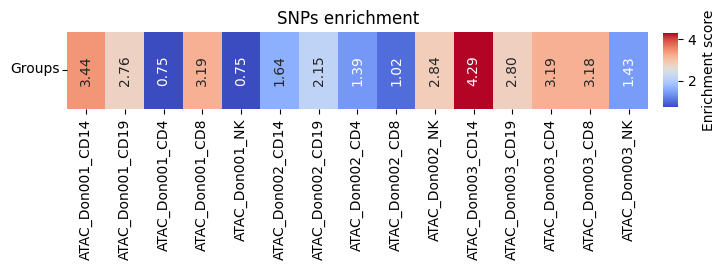

In [27]:
eg = ensgen(genetic=genetic_file, seed=42, output="test_to_remove_INPUT", info=info, beds=beds, bigwigs=bigwigs)
df = eg.process_genetics()
eg.plot_genetics(show=True)

In [28]:
df

,Peak_area,p_succes,GWAS_init,bg_1,bg_2,bg_3,bg_4,bg_5,P_gwas,P_ss1,FOLD1,P_ss2,FOLD2,P_ss3,FOLD3,P_ss4,FOLD4,P_ss5,FOLD5,MEAN
ATAC_Don001_CD14,29535728,0.009686,28,6,9,13,11,8,7.136857e-07,0.071005,5.350760,0.129068,6.912540,0.065986,5.206484,0.110124,6.415165,0.119723,6.667768,3.441958
ATAC_Don001_CD19,43077016,0.014127,34,11,13,10,21,14,2.606461e-06,0.082108,5.143590,0.105599,5.719266,0.063668,4.668550,0.020024,3.287690,0.106677,5.745223,2.762254
ATAC_Don001_CD4,8129950,0.002666,4,1,1,3,1,3,1.465267e-01,0.185183,1.138839,0.185183,1.138839,0.219906,1.268060,0.185183,1.138839,0.219906,1.268060,0.751424
ATAC_Don001_CD8,46554612,0.015267,37,15,17,12,16,11,8.573911e-07,0.102966,6.144835,0.088195,5.752953,0.078448,5.488259,0.098278,6.021384,0.061394,5.006144,3.193321
ATAC_Don001_NK,18839801,0.006178,9,5,3,3,5,6,7.500527e-02,0.155862,1.393492,0.081224,1.031729,0.081224,1.031729,0.155862,1.393492,0.160686,1.416723,0.749573
ATAC_Don002_CD14,20577981,0.006748,15,6,3,6,4,5,2.393702e-03,0.154264,3.228796,0.059737,2.141710,0.154264,3.228796,0.101163,2.634155,0.136915,3.035068,1.635623
ATAC_Don002_CD19,36739514,0.012048,27,11,12,10,21,10,7.449701e-05,0.114465,4.385147,0.115049,4.395468,0.104288,4.204527,0.005566,1.831005,0.104288,4.204527,2.149985
ATAC_Don002_CD4,14698802,0.004820,10,3,4,4,3,5,1.492431e-02,0.150508,2.220354,0.181708,2.465626,0.181708,2.465626,0.150508,2.220354,0.175324,2.414978,1.386243
ATAC_Don002_CD8,17770618,0.005828,10,5,7,3,5,5,3.653067e-02,0.165311,1.838746,0.133764,1.645197,0.096895,1.417919,0.165311,1.838746,0.165311,1.838746,1.015626
ATAC_Don002_NK,48691588,0.015968,37,14,18,10,18,14,2.273054e-06,0.093862,5.492295,0.083251,5.227239,0.034061,3.844952,0.083251,5.227239,0.093862,5.492295,2.842050
